<h1>Explain Problem</h1>

<p>In this project, we study an optimization problem in a distributed network. A time update request starts from a given node and must reach the node connected to the NTP server, possibly through intermediate nodes. The goal is to find the route that minimizes the total connection time. To solve this, we model the network as a weighted graph, formulate the problem as a binary optimization task, transform it into a QUBO, and solve it using QAOA, later comparing the results obtained from simulation and real quantum hardware.</p>

<h1>Import libraries</h1>

<h3>Qiskit libraries</h3>

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import pauli_error, amplitude_damping_error
from IPython.display import display

<h3>Python libraries</h3>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

<h1>Import dataset</h1>

<p>We first load the CSV file and inspect its structure. Each row contains one node, the nodes directly connected to it, and the connection times associated with those links.</p>

In [13]:
df = pd.read_csv('t5-timeupdate.csv', sep=';')
df

,node_name,connected_nodes,connection_times
0,node_1,"node_3,node_4","5.7,10.4"
1,node_2,"node_4,node_ntp","10.2,12.0"
2,node_3,"node_1,node_4,node_ntp","5.7,3.1,35.9"
3,node_4,"node_2,node_3","10.2,3.1"
4,node_ntp,"node_2,node_3","12.0,35.9"


<h1>Build the edge list</h1>

<p>To work with the network more easily, we transform the dataset into an edge list. Each edge will contain a source node, a target node, and the connection time between them.</p>

In [14]:
source_list = []
target_list = []
time_list = []

for i in range(len(df)):
    source_node = df.loc[i, "node_name"]
    connected_nodes = df.loc[i, "connected_nodes"].split(",")
    connection_times = df.loc[i, "connection_times"].split(",")

    for j in range(len(connected_nodes)):
        source_list.append(source_node)
        target_list.append(connected_nodes[j])
        time_list.append(float(connection_times[j]))

edges_df = pd.DataFrame()
edges_df["source"] = source_list
edges_df["target"] = target_list
edges_df["time"] = time_list

edges_df

,source,target,time
0,node_1,node_3,5.7
1,node_1,node_4,10.4
2,node_2,node_4,10.2
3,node_2,node_ntp,12.0
4,node_3,node_1,5.7
5,node_3,node_4,3.1
6,node_3,node_ntp,35.9
7,node_4,node_2,10.2
8,node_4,node_3,3.1
9,node_ntp,node_2,12.0


<h1>Create and draw the graph</h1>

<p>We now create a weighted graph where nodes represent devices in the distributed system and edges represent direct connections weighted by communication time.</p>

In [15]:
G = nx.Graph()

for i in range(len(edges_df)):
    source_node = edges_df.loc[i, "source"]
    target_node = edges_df.loc[i, "target"]
    time_value = edges_df.loc[i, "time"]

    G.add_edge(source_node, target_node, weight=time_value)

print("Nodes:")
print(list(G.nodes))

print("Edges with weights:")
for u, v, data in G.edges(data=True):
    print(u, "--", v, ":", data["weight"])


Nodes:
['node_1', 'node_3', 'node_4', 'node_2', 'node_ntp']
Edges with weights:
node_1 -- node_3 : 5.7
node_1 -- node_4 : 10.4
node_3 -- node_4 : 3.1
node_3 -- node_ntp : 35.9
node_4 -- node_2 : 10.2
node_2 -- node_ntp : 12.0


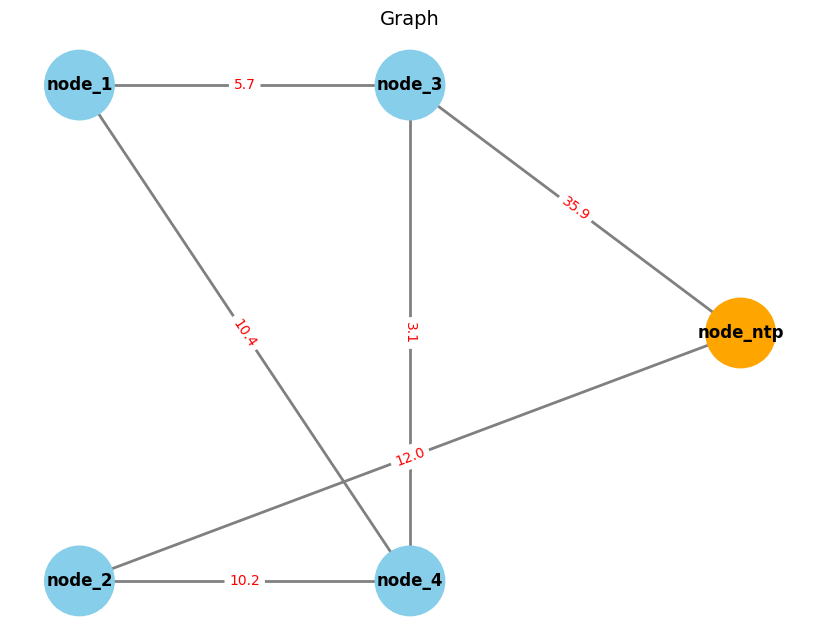

In [22]:
plt.figure(figsize=(8, 6))

pos = {
    "node_1": (0, 2),
    "node_2": (0, 0),
    "node_3": (2, 2),
    "node_4": (2, 0),
    "node_ntp": (4, 1)
}

edge_labels = nx.get_edge_attributes(G, "weight")

node_colors = []
for node in G.nodes():
    if node == "node_ntp":
        node_colors.append("orange")
    else:
        node_colors.append("skyblue")

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2500, font_size=12, font_weight="bold", edge_color="gray", width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color="red")

plt.title("Graph", fontsize=14)
plt.show()

<h1>Insert Inputs</h1>